In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/fedfunds_features.csv"
)

df.head()

,observation_date,FEDFUNDS,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_12,rate_change,pct_change,volatility_12,trend,year,month,quarter
0,1955-06-01,1.64,1.43,1.43,1.35,1.500000,1.215000,0.21,0.146853,0.270773,1,1955,6,2
1,1955-07-01,1.68,1.64,1.43,1.43,1.583333,1.288333,0.04,0.024390,0.267304,1,1955,7,3
2,1955-08-01,1.96,1.68,1.64,1.43,1.760000,1.350000,0.28,0.166667,0.328468,1,1955,8,3
3,1955-09-01,2.18,1.96,1.68,1.64,1.940000,1.442500,0.22,0.112245,0.392501,1,1955,9,3
4,1955-10-01,2.24,2.18,1.96,1.68,2.126667,1.558333,0.06,0.027523,0.406601,1,1955,10,4


In [2]:
rates = df["FEDFUNDS"].values

In [3]:
b = np.mean(rates)

print(b)

4.64238262910798


In [4]:
sigma = np.std(rates)

print(sigma)

3.532349505923603


In [5]:
a = 0.15

In [6]:
def vasicek_simulation(
    r0,
    a,
    b,
    sigma,
    T,
    dt
):
    n_steps = int(T / dt)

    rates = np.zeros(n_steps)

    rates[0] = r0

    for t in range(1, n_steps):

        shock = np.random.normal()

        dr = (
            a * (b - rates[t-1]) * dt
            +
            sigma * np.sqrt(dt) * shock
        )

        rates[t] = rates[t-1] + dr

    return rates

In [7]:
r0 = rates[-1]

In [9]:
future_rates = vasicek_simulation(
    r0=r0,
    a=a,
    b=b,
    sigma=sigma,
    T=5,
    dt=1/12
)

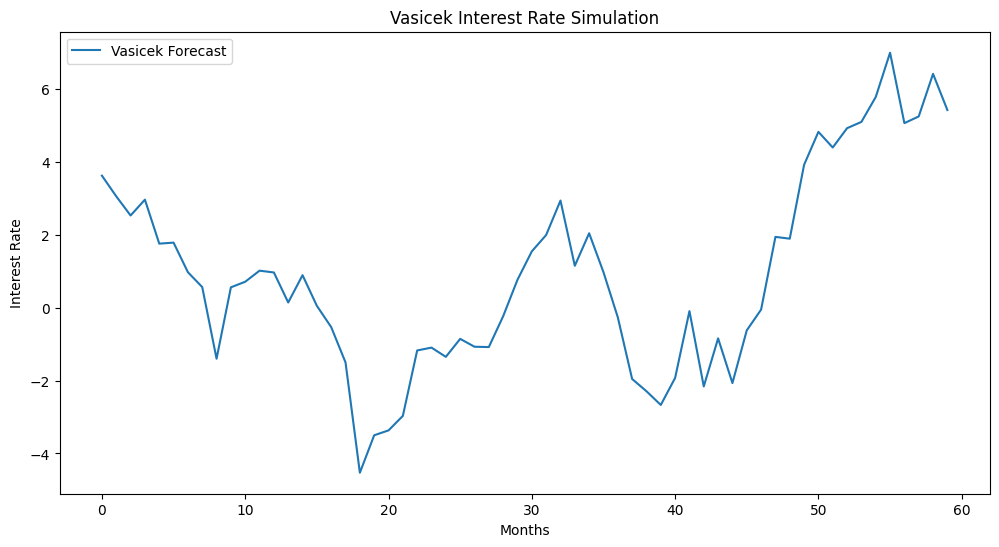

In [10]:
plt.figure(figsize=(12,6))

plt.plot(
    future_rates,
    label="Vasicek Forecast"
)

plt.title(
    "Vasicek Interest Rate Simulation"
)

plt.xlabel("Months")

plt.ylabel("Interest Rate")

plt.legend()

plt.show()

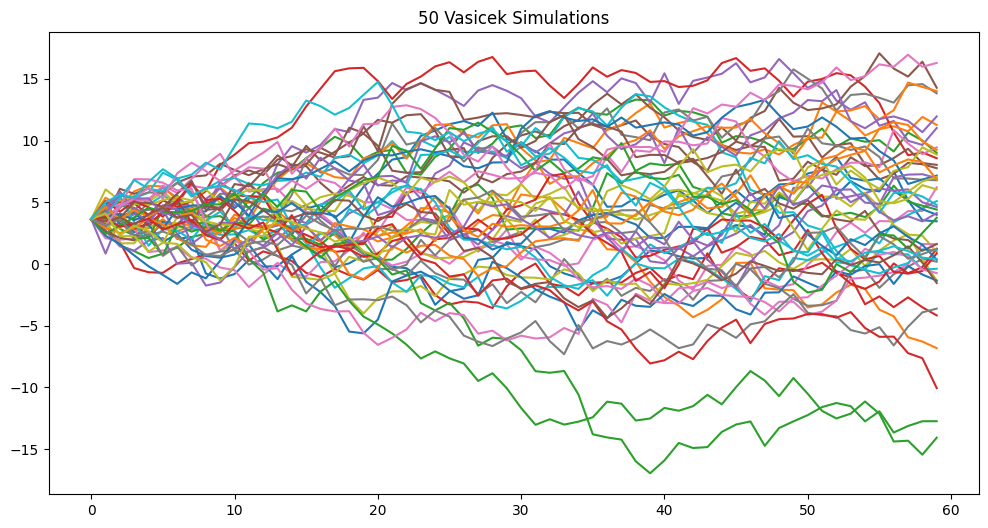

In [11]:
plt.figure(figsize=(12,6))

for i in range(50):

    sim = vasicek_simulation(
        r0,
        a,
        b,
        sigma,
        T=5,
        dt=1/12
    )

    plt.plot(sim)

plt.title(
    "50 Vasicek Simulations"
)

plt.show()

In [12]:
sim_df = pd.DataFrame()

for i in range(100):

    sim_df[f"path_{i}"] = (
        vasicek_simulation(
            r0,
            a,
            b,
            sigma,
            T=5,
            dt=1/12
        )
    )

In [13]:
sim_df.to_csv(
    "../data/processed/vasicek_simulations.csv",
    index=False
)